In [2]:
import yaml2plot as y2p
import numpy as np


In [3]:
from test_all import *

test_op()
test_dc()
test_ac()
test_tran()

Running ngspice in /foss/designs/simulations/tb_ota_5t/test_op
Running ngspice in /foss/designs/simulations/tb_ota_5t/test_dc
Running ngspice in /foss/designs/simulations/tb_ota_5t/test_ac
Running ngspice in /foss/designs/simulations/tb_ota_5t/test_tran


  - v(i_bias)
  - v(in)
  - v(in_n)
  - v(in_p)
  - v(out)
  - i(v_jumper_fb)
  - i(v_jumper_in)
  - i(v_src)
  - i(v_vdda)
  - i(v_vssa)
  - v(vdda)
  - v(vssa)
  - v(x1.net1)
  - v(x1.net2)


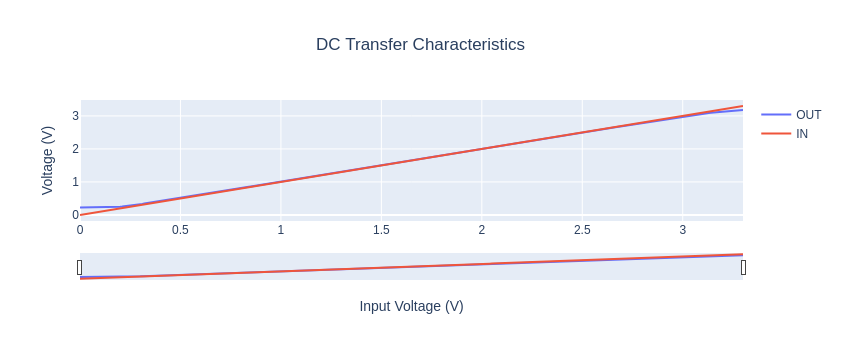

In [4]:
spice_file = "/foss/designs/simulations/tb_ota_5t/test_dc/results.raw"

data = y2p.load_spice_raw(spice_file)

for signal, _ in data.items():
    print(f"  - {signal}")

spec = y2p.PlotSpec.from_yaml("""
title: "DC Transfer Characteristics"
x: 
  label: "Input Voltage (V)"
  signal: "axis"
y:
  - label: "Voltage (V)"
    signals:
      OUT: "v(out)"
      IN:  "v(in)"
""")

fig = y2p.plot(data, spec)

  - v(i_bias)
  - v(in)
  - v(in_n)
  - v(in_p)
  - v(out)
  - i(v_jumper_fb)
  - i(v_jumper_in)
  - i(v_src)
  - i(v_vdda)
  - i(v_vssa)
  - v(vdda)
  - v(vssa)
  - v(x1.net1)
  - v(x1.net2)


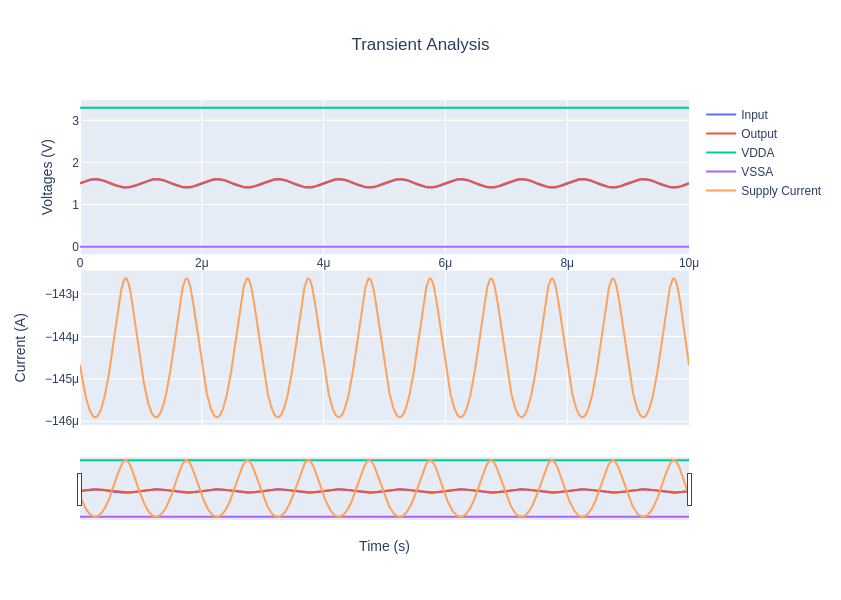

In [5]:

spice_file = "/foss/designs/simulations/tb_ota_5t/test_tran/results.raw"


data = y2p.load_spice_raw(spice_file)

for signal, _ in data.items():
    print(f"  - {signal}")

spec = y2p.PlotSpec.from_yaml("""
title: "Transient Analysis"

X:
  signal: "time"
  label: "Time (s)"

Y:
  - label: "Voltages (V)"
    signals:
      Input: "v(in)"
      Output: "v(out)"
      VDDA: "v(vdda)"
      VSSA: "v(vssa)"
      
  - label: "Current (A)"
    signals:
      Supply Current: "i(v_vdda)"

height: 600
show_rangeslider: true
""")

fig = y2p.plot(data, spec)

  - v(i_bias)
  - v(in)
  - v(in_n)
  - v(in_p)
  - v(out)
  - i(v_jumper_fb)
  - i(v_jumper_in)
  - i(v_src)
  - i(v_vdda)
  - i(v_vssa)
  - v(vdda)
  - v(vssa)
  - v(x1.net1)
  - v(x1.net2)


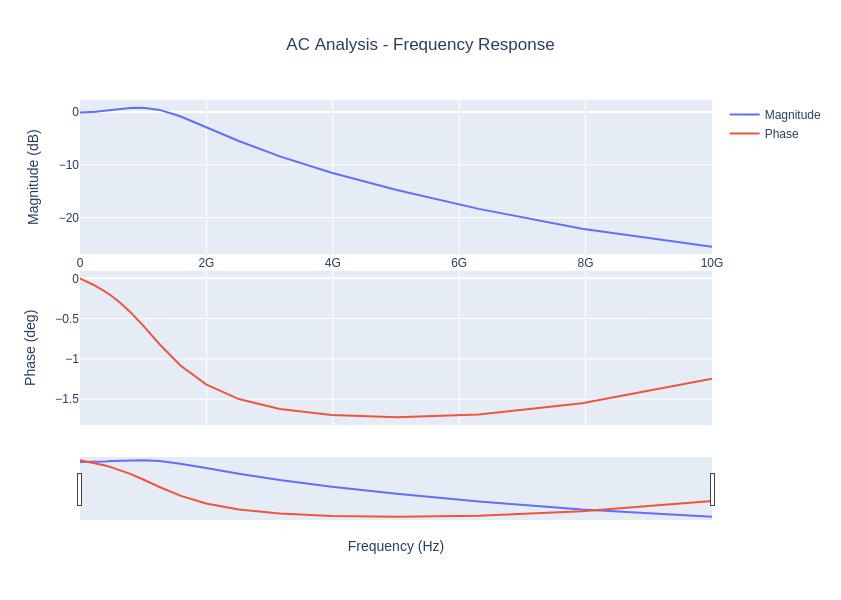

In [6]:
spice_file = "/foss/designs/simulations/tb_ota_5t/test_ac/results.raw"


data = y2p.load_spice_raw(spice_file)

for signal, _ in data.items():
    print(f"  - {signal}")



data["tf_db"] = 20*np.log10(np.abs(data["v(out)"]))
data["tf_phase"] = np.angle(data["v(out)"])


# Now proceed with plotting using YAML configuration

spec = y2p.PlotSpec.from_yaml("""
title: "AC Analysis - Frequency Response"

X:
  signal: "frequency"
  label: "Frequency (Hz)"
  log_scale: true
                                    
Y:
  - label: "Magnitude (dB)"
    signals:
      Magnitude: "tf_db"
  - label: "Phase (deg)"
    signals:
      Phase: "tf_phase"
                            
height: 600
width: 800
show_rangeslider: true
""")

fig = y2p.plot(data, spec)